In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ruchikakumbhar/calories-burnt-prediction")

print("Path to dataset files:", path)

100%|██████████| 236k/236k [00:00<00:00, 23.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ruchikakumbhar/calories-burnt-prediction/versions/1


In [4]:
import pandas as pd

In [5]:
import os

# List contents of the downloaded directory to find the correct file name
print(f"Contents of the downloaded directory ({path}):")
for item in os.listdir(path):
    print(item)

# Corrected file name based on the directory listing
data_file_path = f"{path}/calories.csv"

try:
    df = pd.read_csv(data_file_path)
    # Display the first 5 rows of the DataFrame
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{data_file_path}' was not found. Please check the directory contents listed above and update the file name if necessary.")


Contents of the downloaded directory (/root/.cache/kagglehub/datasets/ruchikakumbhar/calories-burnt-prediction/versions/1):
calories.csv


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [6]:
df.shape

(15000, 9)

In [7]:
df.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [8]:
df['Gender'] = df['Gender'].map({'male':0,'female':1})

In [9]:
df.skew()

,0
User_ID,0.004788
Gender,-0.014135
Age,0.473383
Height,-0.006190
Weight,0.226725
Duration,0.004751
Heart_Rate,-0.010704
Body_Temp,-0.994382
Calories,0.505371


<Axes: xlabel='Calories', ylabel='Count'>

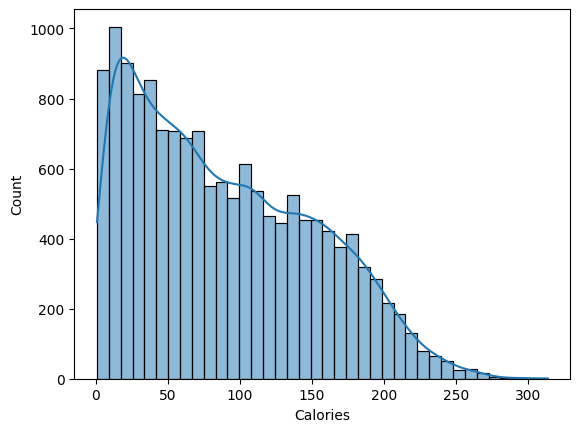

In [10]:
import seaborn as sns
sns.histplot(df['Calories'],kde=True)

In [11]:
# Standard  Scaler -> Distance Based algorithim

X = df.drop(columns=['Calories','User_ID'],axis=1)
y = df['Calories']

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
# Hyperparmeter Tuning.
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor


In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2,5,10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [15]:
randomized = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=1,

)

In [16]:
randomized.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [2, 5, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   verbose=1)

In [17]:
randomized.best_score_

np.float64(0.9964932905058663)

In [18]:
# building random forest model
rfmodel=RandomForestRegressor(max_depth=10,n_estimators=300)

In [19]:
# 1 train
rfmodel.fit(X_train,y_train)

# 2 prediction
y_pred = rfmodel.predict(X_test)

# 3 evaluation
from sklearn.metrics import r2_score,mean_absolute_error

#teasting

r2_score(y_test,y_pred)

0.9972136324841834

In [20]:
r2_score(y_train,rfmodel.predict(X_train))

0.9985606236665336

In [21]:
mean_absolute_error(y_test,y_pred)

2.258908893508782

### Save the trained model

In [22]:
import joblib
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor

# Define and train rfmodel using the parameters from previous cells
# (max_depth=10, n_estimators=300 as found in cell L7YzIpAZhoOw)
# This assumes X_train and y_train are available from previous executed cells.
rfmodel = RandomForestRegressor(max_depth=10, n_estimators=300)
rfmodel.fit(X_train, y_train) # Train the model (as done in cell giuYD99iiRsq)

# Save the trained model to a .pkl file
joblib.dump(rfmodel, 'random_forest_regressor_model.pkl')
print("Model saved successfully as 'random_forest_regressor_model.pkl'")

Model saved successfully as 'random_forest_regressor_model.pkl'
